# 02 — LSTM results

Training curves, final test metrics, and comparison against the four classic baselines from `notebooks/legacy/`.

Run `python scripts/train_lstm.py --config configs/lstm.yaml` and `python scripts/train_lstm.py --config configs/lstm_smote.yaml` first so this notebook has artifacts to load.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fraud.evaluation import compute_metrics, mcnemar_test


## Training curves

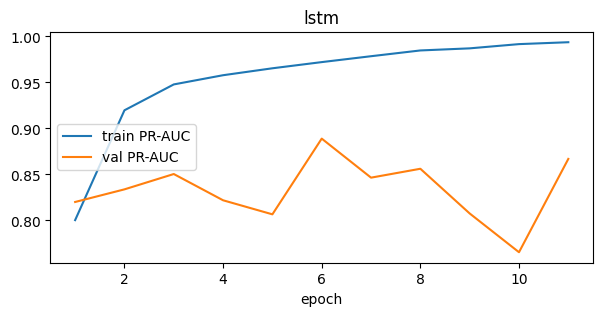

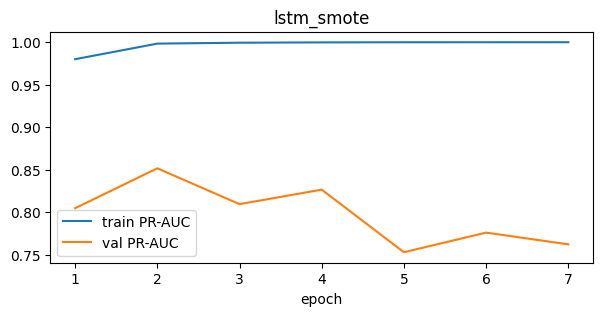

In [2]:
for name in ['lstm', 'lstm_smote']:
    log_path = ROOT / 'models' / name / 'training_log.csv'
    if not log_path.exists():
        print(f'skipping {name} (no training log)')
        continue
    log = pd.read_csv(log_path)
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(log['epoch'], log['train_pr_auc'], label='train PR-AUC')
    ax.plot(log['epoch'], log['val_pr_auc'], label='val PR-AUC')
    ax.set_title(name)
    ax.set_xlabel('epoch'); ax.legend()
    plt.show()


## Test-set metrics for both LSTM configurations

In [3]:
rows = []
for name in ['lstm', 'lstm_smote']:
    pred_path = ROOT / 'models' / name / 'test_predictions.npz'
    thr_path = ROOT / 'models' / name / 'threshold.json'
    if not pred_path.exists():
        continue
    npz = np.load(pred_path)
    thr = json.loads(thr_path.read_text())['threshold']
    m_default = compute_metrics(npz['y_true'], npz['y_proba'], threshold=0.5)
    m_tuned = compute_metrics(npz['y_true'], npz['y_proba'], threshold=thr)
    rows.append({'model': f'{name} (thr=0.5)', **m_default})
    rows.append({'model': f'{name} (tuned)', **m_tuned})
pd.DataFrame(rows)[['model', 'roc_auc', 'pr_auc', 'fraud_precision', 'fraud_recall', 'fraud_f1']]


,model,roc_auc,pr_auc,fraud_precision,fraud_recall,fraud_f1
0,lstm (thr=0.5),0.988265,0.898540,0.596012,0.905828,0.718964
1,lstm (tuned),0.988265,0.898540,0.879243,0.845221,0.861897
2,lstm_smote (thr=0.5),0.986335,0.861697,0.769892,0.834499,0.800895
3,lstm_smote (tuned),0.986335,0.861697,0.525602,0.885315,0.659604


## Comparison vs. classic baselines

Numbers below come from `notebooks/legacy/fraud_detection_notebook.ipynb`. If `data/processed/legacy_predictions.parquet` exists, the cell also runs McNemar tests.

In [4]:
legacy_table = pd.DataFrame([
    {'model': 'SVM',         'roc_auc': 0.9031, 'pr_auc': 0.1014, 'P': 0.18, 'R': 0.38, 'F1': 0.24},
    {'model': 'RF',          'roc_auc': 0.9817, 'pr_auc': 0.5085, 'P': 0.59, 'R': 0.41, 'F1': 0.48},
    {'model': 'SVM + SMOTE', 'roc_auc': 0.8971, 'pr_auc': 0.0857, 'P': 0.03, 'R': 0.68, 'F1': 0.06},
    {'model': 'RF + SMOTE',  'roc_auc': 0.8143, 'pr_auc': 0.1014, 'P': 0.20, 'R': 0.10, 'F1': 0.14},
])
legacy_table


,model,roc_auc,pr_auc,P,R,F1
0,SVM,0.9031,0.1014,0.18,0.38,0.24
1,RF,0.9817,0.5085,0.59,0.41,0.48
2,SVM + SMOTE,0.8971,0.0857,0.03,0.68,0.06
3,RF + SMOTE,0.8143,0.1014,0.20,0.10,0.14


In [5]:
legacy_path = ROOT / 'data/processed/legacy_predictions.parquet'
lstm_pred_path = ROOT / 'models/lstm/test_predictions.npz'
smote_pred_path = ROOT / 'models/lstm_smote/test_predictions.npz'
if not (legacy_path.exists() and lstm_pred_path.exists()):
    print('Run the export cell in notebooks/legacy/ and train both LSTM configs to enable McNemar.')
else:
    legacy = pd.read_parquet(legacy_path)
    npz = np.load(lstm_pred_path)
    thr = json.loads((ROOT / 'models/lstm/threshold.json').read_text())['threshold']
    lstm_pred = (npz['y_proba'] >= thr).astype(int)
    y_true = npz['y_true'].astype(int)
    if len(legacy) != len(y_true):
        print(f'row count mismatch: legacy={len(legacy)} lstm={len(y_true)}')
    else:
        for col in ['svm', 'rf', 'svm_smote', 'rf_smote']:
            if col not in legacy.columns:
                continue
            other = legacy[col].astype(int).to_numpy()
            r = mcnemar_test(y_true, lstm_pred, other)
            print(f"LSTM vs {col:<10} p={r['pvalue']:.3e}  (LSTM-only-correct={r['a_only_correct']}, {col}-only-correct={r['b_only_correct']})")


Run the export cell in notebooks/legacy/ and train both LSTM configs to enable McNemar.
